<div style="background-color: #F4F6F7; padding: 20px; border-radius: 8px; font-family: 'Arial', sans-serif; color: #2E4053;">
  <!-- Logo centrado -->
  <div style="text-align: center; margin-bottom: 15px;">
    <img src="https://drive.google.com/uc?export=view&id=1kjzXfjTiieYAd4azw5bh4UfEg91gUIdh" alt="Logo Institucional" width="250" />
  </div>

  <!-- Título principal -->
  <h1 style="font-size: 36px; font-weight: bold; text-align: right;">
    <strong>Estimación del gradiente geotérmico a partir de base de datos tabular mediante varios modelos de machine learning</strong>
  </h1>

  <!-- Datos del estudiante -->
  <p style="font-size: 22px; text-align: center; margin: 5px 0;">
    <strong>Nombre:</strong> Juan Fernando Castaño Sánchez &nbsp;|&nbsp;
    <strong>Institución:</strong> Universidad Tecnológica de Pereira  &nbsp;|&nbsp;
    <strong>Grupo de investigación en Automática </strong>
  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />

  <!-- Descripción breve -->
  <p style="font-size: 18px; text-align: center; font-style: italic; margin: 5px 0;">
    En este cuaderno se realizó la implemenración y prueba de diferentes modelos de machine learning para la predicción del gradiente geotérmico a partir de datos tabulares.

  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />
</div>

In [1]:
!pip install catboost

In [2]:
!pip install optuna

In [3]:
!pip install contextily geopandas

In [4]:
#Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import optuna
import xgboost as xgb
from tqdm import tqdm
from pathlib import Path
import seaborn as sns
# Modelos
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import ParameterGrid, cross_val_score, KFold
from cuml.ensemble import RandomForestRegressor as CUMLRandomForestRegressor # Import cuML RandomForest

# Métricas y utilidades
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# KFold compartido — mismo split para todos los modelos
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
#!gdown 1gNupu09mzDMq_GLrCJg2Au9UVUMsMCIQ #Base de datos cruda con pesos
!gdown 1OIJY8QtxRYr4HW504Awxama22OAuBJID

Downloading...
From: https://drive.google.com/uc?id=1OIJY8QtxRYr4HW504Awxama22OAuBJID
To: /kaggle/working/data_prep.csv
100%|███████████████████████████████████████| 1.01M/1.01M [00:00<00:00, 119MB/s]


In [7]:
# ==========================================
# 1. CONFIGURACIÓN Y CARGA
# ==========================================
# Asegúrate de que esta ruta sea correcta en tu entorno
#CSV_BASE = Path("/content/data_prep_w.csv")
#CSV_BASE = Path("/content/data_prep.csv")
CSV_BASE = Path("/kaggle/working/data_prep.csv")
TARGET_COL = "Apparent Geothermal Gradient (°C/Km)"
OUT_DIR = Path("/kaggle/working/run_comparison")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
df_base = pd.read_csv(CSV_BASE, delimiter = ";")
display(df_base.head())

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,ID,Unnamed: 23
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.91201,-43.6825,16042.94307,38240.01558,7608.200346,...,28,-54.87500,-107.350006,-155.604003,26430.35964,37574.49384,True,1,1,NaN
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.31133,-43.6825,15471.82439,37942.35231,8075.823613,...,28,-54.87500,-107.350006,-155.604003,26807.50517,37828.18464,True,1,2,NaN
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.26549,-43.6825,15751.33062,38097.70422,7838.753798,...,28,-54.87500,-107.350006,-155.604003,26613.39342,37691.34271,True,1,3,NaN
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.81077,-3.9287,35178.98781,61605.45679,39427.671690,...,20,-0.40625,-26.175018,-58.520164,43126.50631,74754.72808,False,4,4,NaN
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.87962,-2.2424,36371.53398,52965.25327,34306.255130,...,20,-3.53125,-27.399994,-55.094943,43893.01816,84568.77711,False,4,5,NaN


In [9]:
# Eliminar la última columna si su nombre contiene 'Unnamed'
if df_base.columns[-1].startswith('Unnamed'):
    print(f"Eliminando la última columna: {df_base.columns[-1]}")
    df_base = df_base.iloc[:, :-1]

display(df_base.head())

display(df_base.head())

# Guardar el dataframe limpio
output_path = Path("/kaggle/working/data_prep_clean.csv")
df_base.to_csv(output_path, sep=";", index=False)
print(f"CSV guardado en: {output_path}")

Eliminando la última columna: Unnamed: 23


,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,ID
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.91201,-43.6825,16042.94307,38240.01558,7608.200346,...,12107.51887,28,-54.87500,-107.350006,-155.604003,26430.35964,37574.49384,True,1,1
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.31133,-43.6825,15471.82439,37942.35231,8075.823613,...,12521.08152,28,-54.87500,-107.350006,-155.604003,26807.50517,37828.18464,True,1,2
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.26549,-43.6825,15751.33062,38097.70422,7838.753798,...,12309.04873,28,-54.87500,-107.350006,-155.604003,26613.39342,37691.34271,True,1,3
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.81077,-3.9287,35178.98781,61605.45679,39427.671690,...,38740.87859,20,-0.40625,-26.175018,-58.520164,43126.50631,74754.72808,False,4,4
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.87962,-2.2424,36371.53398,52965.25327,34306.255130,...,36506.15976,20,-3.53125,-27.399994,-55.094943,43893.01816,84568.77711,False,4,5


,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,ID
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.91201,-43.6825,16042.94307,38240.01558,7608.200346,...,12107.51887,28,-54.87500,-107.350006,-155.604003,26430.35964,37574.49384,True,1,1
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.31133,-43.6825,15471.82439,37942.35231,8075.823613,...,12521.08152,28,-54.87500,-107.350006,-155.604003,26807.50517,37828.18464,True,1,2
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.26549,-43.6825,15751.33062,38097.70422,7838.753798,...,12309.04873,28,-54.87500,-107.350006,-155.604003,26613.39342,37691.34271,True,1,3
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.81077,-3.9287,35178.98781,61605.45679,39427.671690,...,38740.87859,20,-0.40625,-26.175018,-58.520164,43126.50631,74754.72808,False,4,4
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.87962,-2.2424,36371.53398,52965.25327,34306.255130,...,36506.15976,20,-3.53125,-27.399994,-55.094943,43893.01816,84568.77711,False,4,5


CSV guardado en: /kaggle/working/data_prep_clean.csv


In [10]:
# Definir columnas predictoras (excluyendo ID y Target)
exclude_cols = ['ID','Latitude', 'Longitude', TARGET_COL,'Surface Temperature (°C)', 'Volcanic weight']
# Buscar columnas en el dataframe que coincidan con nombres de coordenadas (ignorando mayúsculas/minúsculas)
tabular_cols = [c for c in df_base.columns if c not in exclude_cols]

# Convertir booleanos a enteros si existen
for col in tabular_cols:
    if df_base[col].dtype == 'bool':
        df_base[col] = df_base[col].astype(int)
print("Tabular columns used (sin lat/lon):", tabular_cols)

Tabular columns used (sin lat/lon): ['Elevation (m)', 'Moho Depth (m)', 'Magnetic Anomaly (nT)', 'Fault', 'Strike-slip Fault', 'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault', 'Normal Fault', 'Active Fault', 'Curie Depth (Km)', 'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)', 'Nearest Basement', 'Nearest Volcano', 'Volcanic domain']


In [11]:
# ==========================================
# 2. PREPROCESAMIENTO
# ==========================================

# A. División Train/Test
train_df, test_df = train_test_split(df_base, test_size=0.2, random_state=42)

# B. Imputación (KNN)
imputer = KNNImputer(n_neighbors=8)
train_df[tabular_cols] = imputer.fit_transform(train_df[tabular_cols])
test_df[tabular_cols] = imputer.transform(test_df[tabular_cols])

# C. Escalado de Features (StandardScaler)
scaler = StandardScaler()
train_df[tabular_cols] = scaler.fit_transform(train_df[tabular_cols])
test_df[tabular_cols] = scaler.transform(test_df[tabular_cols])

# D. Transformación del Target (Log1p + Z-score)

min_target = train_df[TARGET_COL].min()
target_shift = 0.0
if min_target <= 0:
    target_shift = abs(min_target) + 1.0

# Aplicar Log
y_train_log = np.log1p(train_df[TARGET_COL] + target_shift)
y_test_log = np.log1p(test_df[TARGET_COL] + target_shift)

# Aplicar Z-score al target logarítmico
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_log.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test_log.values.reshape(-1, 1)).flatten()

# Guardar transformadores para invertir después
joblib.dump(target_scaler, OUT_DIR / "target_scaler.pkl")
joblib.dump({"shift": target_shift}, OUT_DIR / "target_shift.json")

# Definir X e y finales para entrenamiento
X_train = train_df[tabular_cols]
X_test = test_df[tabular_cols]
# Usamos el target escalado para entrenar
y_train_train = y_train_scaled

print(f"Datos listos. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Datos listos. Train shape: (3634, 17), Test shape: (909, 17)


## Desnormalización y Cálculo de Métricas

In [12]:
# 1. Cargar transformadores (scaler y shift)
target_scaler = joblib.load(OUT_DIR / "target_scaler.pkl")
target_shift_data = joblib.load(OUT_DIR / "target_shift.json")
target_shift = target_shift_data["shift"]

print("Transformadores del target cargados exitosamente.")

Transformadores del target cargados exitosamente.


In [13]:
# 2. Función para desnormalizar el target
def inverse_target_transform(scaled_values, scaler, shift):
    # Inverse Z-score
    log_values = scaler.inverse_transform(np.array(scaled_values).reshape(-1, 1)).flatten()
    # Inverse log1p
    original_values = np.expm1(log_values) - shift
    return original_values

print("Función inverse_target_transform definida.")

Función inverse_target_transform definida.


# **CatBoost**

In [14]:
def objective_cb(trial):
  param_grid = {
    "depth": trial.suggest_int("depth", 6, 10),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
    "iterations": trial.suggest_int("iterations", 200, 500),
    "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 10),
    "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
  }
  model_cb = CatBoostRegressor(verbose=0, task_type="GPU", **param_grid)

  mae_folds, mse_folds, rmse_folds, r2_folds = [], [], [], []
  X_tr = X_train.values if hasattr(X_train, 'values') else X_train
  y_tr = np.array(y_train_train)

  for train_idx, val_idx in kf.split(X_tr):
      X_f_tr, X_f_val = X_tr[train_idx], X_tr[val_idx]
      y_f_tr, y_f_val = y_tr[train_idx], y_tr[val_idx]
      model_cb.fit(X_f_tr, y_f_tr)
      preds = model_cb.predict(X_f_val)
      mae_folds.append(mean_absolute_error(y_f_val, preds))
      mse_folds.append(mean_squared_error(y_f_val, preds))
      rmse_folds.append(np.sqrt(mean_squared_error(y_f_val, preds)))
      r2_folds.append(r2_score(y_f_val, preds))

  trial.set_user_attr("cv_mae_mean",  float(np.mean(mae_folds)))
  trial.set_user_attr("cv_mae_std",   float(np.std(mae_folds)))
  trial.set_user_attr("cv_mse_mean",  float(np.mean(mse_folds)))
  trial.set_user_attr("cv_mse_std",   float(np.std(mse_folds)))
  trial.set_user_attr("cv_rmse_mean", float(np.mean(rmse_folds)))
  trial.set_user_attr("cv_rmse_std",  float(np.std(rmse_folds)))
  trial.set_user_attr("cv_r2_mean",   float(np.mean(r2_folds)))
  trial.set_user_attr("cv_r2_std",    float(np.std(r2_folds)))
  return -np.mean(mse_folds)


In [15]:
study_cb = optuna.create_study(direction='maximize', sampler = optuna.samplers.RandomSampler(seed=42))


[I 2026-06-04 20:26:13,145] A new study created in memory with name: no-name-cf80b88f-becc-4ed2-89e4-e95cca662f79


In [16]:
study_cb.optimize(objective_cb, n_trials=100)

[I 2026-06-04 20:26:30,214] Trial 0 finished with value: -0.5515182772977684 and parameters: {'depth': 7, 'learning_rate': 0.08927180304353628, 'iterations': 420, 'min_data_in_leaf': 6, 'l2_leaf_reg': 2}. Best is trial 0 with value: -0.5515182772977684.
[I 2026-06-04 20:26:44,274] Trial 1 finished with value: -0.5543274484209544 and parameters: {'depth': 6, 'learning_rate': 0.011430983876313222, 'iterations': 460, 'min_data_in_leaf': 7, 'l2_leaf_reg': 8}. Best is trial 0 with value: -0.5515182772977684.
[I 2026-06-04 20:26:59,127] Trial 2 finished with value: -0.5478781948112751 and parameters: {'depth': 6, 'learning_rate': 0.09330606024425668, 'iterations': 450, 'min_data_in_leaf': 3, 'l2_leaf_reg': 2}. Best is trial 2 with value: -0.5478781948112751.
[I 2026-06-04 20:27:10,015] Trial 3 finished with value: -0.5417872736584877 and parameters: {'depth': 6, 'learning_rate': 0.02014847788415866, 'iterations': 357, 'min_data_in_leaf': 5, 'l2_leaf_reg': 3}. Best is trial 3 with value: -0.5

In [17]:
# Métricas CV del mejor trial — CatBoost
best = study_cb.best_trial
print(f"CatBoost — CV MAE  (media ± std): {best.user_attrs['cv_mae_mean']:.6f} ± {best.user_attrs['cv_mae_std']:.6f}")
print(f"CatBoost — CV MSE  (media ± std): {best.user_attrs['cv_mse_mean']:.6f} ± {best.user_attrs['cv_mse_std']:.6f}")
print(f"CatBoost — CV RMSE (media ± std): {best.user_attrs['cv_rmse_mean']:.6f} ± {best.user_attrs['cv_rmse_std']:.6f}")
print(f"CatBoost — CV R²   (media ± std): {best.user_attrs['cv_r2_mean']:.6f} ± {best.user_attrs['cv_r2_std']:.6f}")


CatBoost — CV MAE  (media ± std): 0.488532 ± 0.008970
CatBoost — CV MSE  (media ± std): 0.529872 ± 0.038462
CatBoost — CV RMSE (media ± std): 0.727432 ± 0.026712
CatBoost — CV R²   (media ± std): 0.469891 ± 0.034248


In [18]:
study_cb.best_params

{'depth': 10,
 'learning_rate': 0.025859354325557908,
 'iterations': 311,
 'min_data_in_leaf': 8,
 'l2_leaf_reg': 4}

In [19]:
best_params_cb = study_cb.best_params

In [20]:
best_catb_model = CatBoostRegressor(**best_params_cb)
best_catb_model.fit(X_train, y_train_train)

0:	learn: 0.9904436	total: 52.4ms	remaining: 16.2s
1:	learn: 0.9805092	total: 94.3ms	remaining: 14.6s
2:	learn: 0.9710242	total: 122ms	remaining: 12.5s
3:	learn: 0.9617218	total: 151ms	remaining: 11.6s
4:	learn: 0.9529160	total: 177ms	remaining: 10.8s
5:	learn: 0.9446007	total: 202ms	remaining: 10.3s
6:	learn: 0.9364736	total: 230ms	remaining: 9.97s
7:	learn: 0.9283930	total: 255ms	remaining: 9.64s
8:	learn: 0.9208222	total: 279ms	remaining: 9.36s
9:	learn: 0.9137467	total: 302ms	remaining: 9.09s
10:	learn: 0.9066626	total: 326ms	remaining: 8.89s
11:	learn: 0.8998729	total: 353ms	remaining: 8.8s
12:	learn: 0.8936018	total: 380ms	remaining: 8.7s
13:	learn: 0.8869449	total: 406ms	remaining: 8.61s
14:	learn: 0.8809912	total: 433ms	remaining: 8.55s
15:	learn: 0.8746819	total: 462ms	remaining: 8.51s
16:	learn: 0.8686112	total: 486ms	remaining: 8.4s
17:	learn: 0.8626253	total: 512ms	remaining: 8.33s
18:	learn: 0.8568183	total: 537ms	remaining: 8.25s
19:	learn: 0.8513511	total: 563ms	remainin

CatBoostRegressor(depth=10, iterations=311, l2_leaf_reg=4, learning_rate=0.025859354325557908, loss_function='RMSE', min_data_in_leaf=8)

In [21]:
joblib.dump(best_catb_model, OUT_DIR / "catboost_model.pkl")
print("Modelo entrenado y guardado.")

Modelo entrenado y guardado.


In [22]:
best_catb_model = joblib.load(OUT_DIR / 'catboost_model.pkl')

In [23]:
y_train_pred = best_catb_model.predict(X_train)

# Metrics for the training set
mae_train_catb = mean_absolute_error(y_train_train, y_train_pred)
r2_train_catb = r2_score(y_train_train, y_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train_catb}")
print(f"R-squared: {r2_train_catb}")

Training Set Metrics:
MAE: 0.4208003171180043
R-squared: 0.6220173055338492


In [24]:
# Predictions on the test set
y_test_pred = best_catb_model.predict(X_test)

# Metrics for the test set
mae_test_catb = mean_absolute_error(y_test_scaled, y_test_pred)
mse_test_catb = mean_squared_error(y_test_scaled, y_test_pred)
rmse_test_catb = np.sqrt(mse_test_catb)
r2_test_catb = r2_score(y_test_scaled, y_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test_catb}")
print(f"MSE: {mse_test_catb}")
print(f"RMSE (CatBoost): {rmse_test_catb}")
print(f"R-squared: {r2_test_catb}")


Test Set Metrics:
MAE: 0.49885100914637176
MSE: 0.60682824870073
RMSE (CatBoost): 0.7789918155543933
R-squared: 0.4389631058943584


In [25]:
# --- Métricas Desnormalizadas para CatBoostRegressor ---

# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_catb_train_pred_original_scale = inverse_target_transform(y_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_catb_train_denormalized = mean_absolute_error(y_train_original_scale, y_catb_train_pred_original_scale)
r2_catb_train_denormalized = r2_score(y_train_original_scale, y_catb_train_pred_original_scale)
rmse_catb_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_catb_train_pred_original_scale)**2))
print("\nCatBoostRegressor Denormalized Metrics (Training Set):")
print(f"MAE: {mae_catb_train_denormalized:.4f}")
print(f"RMSE: {rmse_catb_train_denormalized:.4f}")
print(f"R-squared: {r2_catb_train_denormalized:.4f}")


CatBoostRegressor Denormalized Metrics (Training Set):
MAE: 2.3797
RMSE: 3.8335
R-squared: 0.5894


In [26]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_catb_test_pred_original_scale = inverse_target_transform(y_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_catb_denormalized = mean_absolute_error(y_test_original_scale, y_catb_test_pred_original_scale)
r2_catb_denormalized = r2_score(y_test_original_scale, y_catb_test_pred_original_scale)
rmse_catb_denormalized = np.sqrt(np.mean((y_test_original_scale - y_catb_test_pred_original_scale)**2))
print("\nCatBoostRegressor Denormalized Metrics (Test Set):")
print(f"MAE: {mae_catb_denormalized:.4f}")
print(f"RMSE: {rmse_catb_denormalized:.4f}")
print(f"R-squared: {r2_catb_denormalized:.4f}")


CatBoostRegressor Denormalized Metrics (Test Set):
MAE: 2.8165
RMSE: 4.8473
R-squared: 0.3979


# **XGBOOST**

In [27]:
# Convertir datos a DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train_train)
dtest = xgb.DMatrix(X_test, label=y_test_scaled)

def objective_xgb(trial):
  params = {
      'objective': 'reg:squarederror',
      'eval_metric': 'rmse',
      'tree_method': 'hist',
      'device': 'cuda',
      'max_depth': trial.suggest_int('max_depth', 3, 15),
      'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'gamma': trial.suggest_float('gamma', 0.0, 0.5),
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
      'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
      'random_state': 42
  }
  model_xgb = XGBRegressor(**params)

  mae_folds, mse_folds, rmse_folds, r2_folds = [], [], [], []
  X_tr = X_train.values if hasattr(X_train, 'values') else X_train
  y_tr = np.array(y_train_train)

  for train_idx, val_idx in kf.split(X_tr):
      X_f_tr, X_f_val = X_tr[train_idx], X_tr[val_idx]
      y_f_tr, y_f_val = y_tr[train_idx], y_tr[val_idx]
      model_xgb.fit(X_f_tr, y_f_tr)
      preds = model_xgb.predict(X_f_val)
      mae_folds.append(mean_absolute_error(y_f_val, preds))
      mse_folds.append(mean_squared_error(y_f_val, preds))
      rmse_folds.append(np.sqrt(mean_squared_error(y_f_val, preds)))
      r2_folds.append(r2_score(y_f_val, preds))

  trial.set_user_attr("cv_mae_mean",  float(np.mean(mae_folds)))
  trial.set_user_attr("cv_mae_std",   float(np.std(mae_folds)))
  trial.set_user_attr("cv_mse_mean",  float(np.mean(mse_folds)))
  trial.set_user_attr("cv_mse_std",   float(np.std(mse_folds)))
  trial.set_user_attr("cv_rmse_mean", float(np.mean(rmse_folds)))
  trial.set_user_attr("cv_rmse_std",  float(np.std(rmse_folds)))
  trial.set_user_attr("cv_r2_mean",   float(np.mean(r2_folds)))
  trial.set_user_attr("cv_r2_std",    float(np.std(r2_folds)))
  return -np.mean(mse_folds)


In [28]:
study_xgb = optuna.create_study(direction='maximize', sampler = optuna.samplers.RandomSampler(seed=42))


[I 2026-06-04 20:53:22,362] A new study created in memory with name: no-name-29b3ee3f-70d5-4615-8b67-92ccd8648ef7


In [29]:
study_xgb.optimize(objective_xgb, n_trials=100)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:53:23] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-06-04 20:53:27,061] Trial 0 finished with value: -0.6209943142766251 and parameters: {'max_depth': 7, 'learning_rate': 0.1667521176194013, 'n_estimators': 759, 'gamma': 0.2993292420985183, 'min_child_weight': 2, 'colsample_bytree': 0.5779972601681014, 'subsample': 0.5290418060840998, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.4016725176148133}. Best is trial 0 with value: -0.6209943142766251.
[I 2026-06-04 20:53:41,870] Trial 1

In [30]:
# Métricas CV del mejor trial — XGBoost
best = study_xgb.best_trial
print(f"XGBoost — CV MAE  (media ± std): {best.user_attrs['cv_mae_mean']:.6f} ± {best.user_attrs['cv_mae_std']:.6f}")
print(f"XGBoost — CV MSE  (media ± std): {best.user_attrs['cv_mse_mean']:.6f} ± {best.user_attrs['cv_mse_std']:.6f}")
print(f"XGBoost — CV RMSE (media ± std): {best.user_attrs['cv_rmse_mean']:.6f} ± {best.user_attrs['cv_rmse_std']:.6f}")
print(f"XGBoost — CV R²   (media ± std): {best.user_attrs['cv_r2_mean']:.6f} ± {best.user_attrs['cv_r2_std']:.6f}")


XGBoost — CV MAE  (media ± std): 0.485491 ± 0.011532
XGBoost — CV MSE  (media ± std): 0.527639 ± 0.041839
XGBoost — CV RMSE (media ± std): 0.725791 ± 0.029445
XGBoost — CV R²   (media ± std): 0.472120 ± 0.038393


In [31]:
study_xgb.best_params

{'max_depth': 6,
 'learning_rate': 0.007048979113298945,
 'n_estimators': 908,
 'gamma': 0.4502090285816652,
 'min_child_weight': 7,
 'colsample_bytree': 0.6695148955243504,
 'subsample': 0.6746047873063304,
 'reg_alpha': 0.7259556788702394,
 'reg_lambda': 1.8456653899288655}

In [32]:
best_params_xgb = study_xgb.best_params

In [33]:
#Entrenar
best_xgb_model = XGBRegressor(**best_params_xgb)
best_xgb_model.fit(X_train, y_train_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6695148955243504, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.4502090285816652, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.007048979113298945,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=7, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=908, n_jobs=None,
             num_parallel_tree=None, ...)

In [34]:
# Guardar modelo XGBOOST
joblib.dump(best_xgb_model, OUT_DIR / "xgboost_model.pkl")
print("Modelo entrenado y guardado.")

Modelo entrenado y guardado.


In [35]:
# Cargar modelo
best_xgb_model = joblib.load(OUT_DIR / 'xgboost_model.pkl')

In [36]:
# Predictions on the training set
y_xgb_train_pred = best_xgb_model.predict(X_train)

# Metrics for the training set
mae_train_xgb = mean_absolute_error(y_train_train, y_xgb_train_pred)
mse_train_xgb = mean_squared_error(y_train_train, y_xgb_train_pred)
rmse_train_xgb = np.sqrt(mse_train_xgb)
r2_train_xgb = r2_score(y_train_train, y_xgb_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"R-squared: {r2_train_xgb}")

Training Set Metrics:
MAE: 0.39750875653561074
RMSE: 0.5805238128436743
R-squared: 0.6629921027214427


In [37]:
# Predictions on the test set
y_xgb_test_pred = best_xgb_model.predict(X_test)

# Metrics for the test set
mae_test_xgb = mean_absolute_error(y_test_scaled, y_xgb_test_pred)
mse_test_xgb = mean_squared_error(y_test_scaled, y_xgb_test_pred)
rmse_test_xgb = np.sqrt(mse_test_xgb)
r2_test_xgb = r2_score(y_test_scaled, y_xgb_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test_xgb}")
print(f"MSE: {mse_test_xgb}")
print(f"RMSE: {rmse_test_xgb}")
print(f"R-squared: {r2_test_xgb}")


Test Set Metrics:
MAE: 0.4971765453918745
MSE: 0.6141321485048684
RMSE: 0.7836658398226047
R-squared: 0.43221035951225395


In [38]:
# --- Métricas Desnormalizadas para XGBoostRegressor ---

# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_xgb_train_pred_original_scale = inverse_target_transform(y_xgb_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_xgb_train_denormalized = mean_absolute_error(y_train_original_scale, y_xgb_train_pred_original_scale)
r2_xgb_train_denormalized = r2_score(y_train_original_scale, y_xgb_train_pred_original_scale)
rmse_xgb_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_xgb_train_pred_original_scale)**2))
print("\nXGBRegressor Denormalized Metrics (Training Set):")
print(f"MAE: {mae_xgb_train_denormalized:.4f}")
print(f"RMSE: {rmse_xgb_train_denormalized:.4f}")
print(f"R-squared: {r2_xgb_train_denormalized:.4f}")


XGBRegressor Denormalized Metrics (Training Set):
MAE: 2.2483
RMSE: 3.6153
R-squared: 0.6348


In [39]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_xgb_test_pred_original_scale = inverse_target_transform(y_xgb_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_xgb_denormalized = mean_absolute_error(y_test_original_scale, y_xgb_test_pred_original_scale)
r2_xgb_denormalized = r2_score(y_test_original_scale, y_xgb_test_pred_original_scale)
rmse_xgb_denormalized = np.sqrt(np.mean((y_test_original_scale - y_xgb_test_pred_original_scale)**2))
print("\nXGBRegressor Denormalized Metrics (Test Set):")
print(f"MAE: {mae_xgb_denormalized:.4f}")
print(f"RMSE: {rmse_xgb_denormalized:.4f}")
print(f"R-squared: {r2_xgb_denormalized:.4f}")


XGBRegressor Denormalized Metrics (Test Set):
MAE: 2.8065
RMSE: 4.8742
R-squared: 0.3911


# **LIGHTGBM**

In [40]:
def objective_lgb(trial):
  params = {
      "objective": "regression",
      "metric": "rmse",
      "verbose": -1,
      "boosting_type": "gbdt",
      "n_jobs": -1,
      "random_state": 42,
      "num_leaves": trial.suggest_categorical("num_leaves", [31, 63, 127]),
      "max_depth": trial.suggest_categorical("max_depth", [-1, 10, 15]),
      "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
      "n_estimators": trial.suggest_categorical("n_estimators", [500, 1000]),
      "subsample": trial.suggest_categorical("subsample", [0.8]),
      "bagging_freq": trial.suggest_categorical("bagging_freq", [5]),
      "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.8, 1.0]),
      "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1]),
      "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1]),
      "device": "gpu",
      "max_bin": 63,
      "gpu_use_dp": False
  }
  model_lgb = LGBMRegressor(**params)

  mae_folds, mse_folds, rmse_folds, r2_folds = [], [], [], []
  X_tr = X_train.values if hasattr(X_train, 'values') else X_train
  y_tr = np.array(y_train_train)

  for train_idx, val_idx in kf.split(X_tr):
      X_f_tr, X_f_val = X_tr[train_idx], X_tr[val_idx]
      y_f_tr, y_f_val = y_tr[train_idx], y_tr[val_idx]
      model_lgb.fit(X_f_tr, y_f_tr)
      preds = model_lgb.predict(X_f_val)
      mae_folds.append(mean_absolute_error(y_f_val, preds))
      mse_folds.append(mean_squared_error(y_f_val, preds))
      rmse_folds.append(np.sqrt(mean_squared_error(y_f_val, preds)))
      r2_folds.append(r2_score(y_f_val, preds))

  trial.set_user_attr("cv_mae_mean",  float(np.mean(mae_folds)))
  trial.set_user_attr("cv_mae_std",   float(np.std(mae_folds)))
  trial.set_user_attr("cv_mse_mean",  float(np.mean(mse_folds)))
  trial.set_user_attr("cv_mse_std",   float(np.std(mse_folds)))
  trial.set_user_attr("cv_rmse_mean", float(np.mean(rmse_folds)))
  trial.set_user_attr("cv_rmse_std",  float(np.std(rmse_folds)))
  trial.set_user_attr("cv_r2_mean",   float(np.mean(r2_folds)))
  trial.set_user_attr("cv_r2_std",    float(np.std(r2_folds)))
  return -np.mean(mse_folds)


In [41]:
study_lgb = optuna.create_study(direction='maximize', sampler = optuna.samplers.RandomSampler(seed=42))

[I 2026-06-04 21:00:38,917] A new study created in memory with name: no-name-1db59ef9-85b5-44a5-be34-799a9c6dc88d


In [42]:
study_lgb.optimize(objective_lgb, n_trials=100)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

In [43]:
# Métricas CV del mejor trial — LightGBM
best = study_lgb.best_trial
print(f"LightGBM — CV MAE  (media ± std): {best.user_attrs['cv_mae_mean']:.6f} ± {best.user_attrs['cv_mae_std']:.6f}")
print(f"LightGBM — CV MSE  (media ± std): {best.user_attrs['cv_mse_mean']:.6f} ± {best.user_attrs['cv_mse_std']:.6f}")
print(f"LightGBM — CV RMSE (media ± std): {best.user_attrs['cv_rmse_mean']:.6f} ± {best.user_attrs['cv_rmse_std']:.6f}")
print(f"LightGBM — CV R²   (media ± std): {best.user_attrs['cv_r2_mean']:.6f} ± {best.user_attrs['cv_r2_std']:.6f}")


LightGBM — CV MAE  (media ± std): 0.488401 ± 0.011686
LightGBM — CV MSE  (media ± std): 0.531190 ± 0.041641
LightGBM — CV RMSE (media ± std): 0.728245 ± 0.029144
LightGBM — CV R²   (media ± std): 0.468647 ± 0.036918


In [44]:
study_lgb.best_params

{'num_leaves': 31,
 'max_depth': 10,
 'learning_rate': 0.01,
 'n_estimators': 500,
 'subsample': 0.8,
 'bagging_freq': 5,
 'colsample_bytree': 0.8,
 'reg_alpha': 0.1,
 'reg_lambda': 0.1}

In [45]:
best_params_lgb = study_lgb.best_params

In [46]:
#Entrenar
best_lgb_model = LGBMRegressor(**best_params_lgb)
best_lgb_model.fit(X_train, y_train_train)

LGBMRegressor(bagging_freq=5, colsample_bytree=0.8, learning_rate=0.01,
              max_depth=10, n_estimators=500, reg_alpha=0.1, reg_lambda=0.1,
              subsample=0.8)

In [47]:
joblib.dump(best_lgb_model, OUT_DIR / "lightgbm_model.pkl")
print("Modelo entrenado y guardado.")

Modelo entrenado y guardado.


In [48]:
best_lgb_model = joblib.load(OUT_DIR / 'lightgbm_model.pkl')

In [49]:
# Predictions on the training set
y_lgb_train_pred = best_lgb_model.predict(X_train)

# Metrics for the training set
mae_train_lgb = mean_absolute_error(y_train_train, y_lgb_train_pred)
mse_train_lgb = mean_squared_error(y_train_train, y_lgb_train_pred)
rmse_train_lgb = np.sqrt(mse_train_lgb)
r2_train_lgb = r2_score(y_train_train, y_lgb_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train_lgb}")
print(f"RMSE: {rmse_train_lgb}")
print(f"R-squared: {r2_train_lgb}")

Training Set Metrics:
MAE: 0.4035550928292502
RMSE: 0.5925129518536307
R-squared: 0.648928401885697


In [50]:
# Predictions on the test set
y_lgb_test_pred = best_lgb_model.predict(X_test)

# Metrics for the test set
mae_test_lgb = mean_absolute_error(y_test_scaled, y_lgb_test_pred)
mse_test_lgb = mean_squared_error(y_test_scaled, y_lgb_test_pred)
rmse_test_lgb = np.sqrt(mse_test_lgb)
r2_test_lgb = r2_score(y_test_scaled, y_lgb_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test_lgb}")
print(f"MSE: {mse_test_lgb}")
print(f"RMSE: {rmse_test_lgb}")
print(f"R-squared: {r2_test_lgb}")


Test Set Metrics:
MAE: 0.5005024222711064
MSE: 0.6180354071349613
RMSE: 0.7861522798637433
R-squared: 0.42860164138911605


In [51]:
# --- Métricas Desnormalizadas para LightGBM ---

# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_lgb_train_pred_original_scale = inverse_target_transform(y_lgb_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_lgb_train_denormalized = mean_absolute_error(y_train_original_scale, y_lgb_train_pred_original_scale)
r2_lgb_train_denormalized = r2_score(y_train_original_scale, y_lgb_train_pred_original_scale)
rmse_lgb_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_lgb_train_pred_original_scale)**2))
print("\nLightGBM Denormalized Metrics (Training Set):")
print(f"MAE: {mae_lgb_train_denormalized:.4f}")
print(f"RMSE: {rmse_lgb_train_denormalized:.4f}")
print(f"R-squared: {r2_lgb_train_denormalized:.4f}")


LightGBM Denormalized Metrics (Training Set):
MAE: 2.2858
RMSE: 3.7029
R-squared: 0.6169


In [52]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_lgb_test_pred_original_scale = inverse_target_transform(y_lgb_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_lgb_denormalized = mean_absolute_error(y_test_original_scale, y_lgb_test_pred_original_scale)
r2_lgb_denormalized = r2_score(y_test_original_scale, y_lgb_test_pred_original_scale)
rmse_lgb_denormalized = np.sqrt(np.mean((y_test_original_scale - y_lgb_test_pred_original_scale)**2))
print("\nLightGBM Denormalized Metrics (Test Set):")
print(f"MAE: {mae_lgb_denormalized:.4f}")
print(f"RMSE: {rmse_lgb_denormalized:.4f}")
print(f"R-squared: {r2_lgb_denormalized:.4f}")


LightGBM Denormalized Metrics (Test Set):
MAE: 2.8274
RMSE: 4.8901
R-squared: 0.3872


# **cuML RandomForest**

In [53]:
def objective_cuml_rf(trial):
  params = {
      "n_estimators": trial.suggest_int("n_estimators", 50, 500),
      "max_depth": trial.suggest_int("max_depth", 2, 32),
      "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7, 0.9]),
      "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
      "random_state": 42
  }
  model_cuml_rf = CUMLRandomForestRegressor(**params)

  mae_folds, mse_folds, rmse_folds, r2_folds = [], [], [], []
  X_tr = X_train.values if hasattr(X_train, 'values') else X_train
  y_tr = np.array(y_train_train)

  for train_idx, val_idx in kf.split(X_tr):
      X_f_tr, X_f_val = X_tr[train_idx], X_tr[val_idx]
      y_f_tr, y_f_val = y_tr[train_idx], y_tr[val_idx]
      model_cuml_rf.fit(X_f_tr, y_f_tr)
      preds = model_cuml_rf.predict(X_f_val)
      mae_folds.append(mean_absolute_error(y_f_val, preds))
      mse_folds.append(mean_squared_error(y_f_val, preds))
      rmse_folds.append(np.sqrt(mean_squared_error(y_f_val, preds)))
      r2_folds.append(r2_score(y_f_val, preds))

  trial.set_user_attr("cv_mae_mean",  float(np.mean(mae_folds)))
  trial.set_user_attr("cv_mae_std",   float(np.std(mae_folds)))
  trial.set_user_attr("cv_mse_mean",  float(np.mean(mse_folds)))
  trial.set_user_attr("cv_mse_std",   float(np.std(mse_folds)))
  trial.set_user_attr("cv_rmse_mean", float(np.mean(rmse_folds)))
  trial.set_user_attr("cv_rmse_std",  float(np.std(rmse_folds)))
  trial.set_user_attr("cv_r2_mean",   float(np.mean(r2_folds)))
  trial.set_user_attr("cv_r2_std",    float(np.std(r2_folds)))
  return -np.mean(mse_folds)


In [54]:
study_cuml_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler(seed=42))

[I 2026-06-04 21:33:45,523] A new study created in memory with name: no-name-96323b66-894d-440f-95d5-72c1e37310ee


In [55]:
study_cuml_rf.optimize(objective_cuml_rf, n_trials=100)

[I 2026-06-04 21:33:49,648] Trial 0 finished with value: -0.5358474037603271 and parameters: {'n_estimators': 218, 'max_depth': 31, 'max_features': 'sqrt', 'min_samples_leaf': 18}. Best is trial 0 with value: -0.5358474037603271.
[I 2026-06-04 21:33:54,648] Trial 1 finished with value: -0.5349386526744796 and parameters: {'n_estimators': 321, 'max_depth': 23, 'max_features': 'log2', 'min_samples_leaf': 4}. Best is trial 1 with value: -0.5349386526744796.
[I 2026-06-04 21:33:57,187] Trial 2 finished with value: -0.5304136031774769 and parameters: {'n_estimators': 187, 'max_depth': 18, 'max_features': 0.5, 'min_samples_leaf': 8}. Best is trial 2 with value: -0.5304136031774769.
[I 2026-06-04 21:34:01,760] Trial 3 finished with value: -0.5476301016349525 and parameters: {'n_estimators': 255, 'max_depth': 26, 'max_features': 0.9, 'min_samples_leaf': 4}. Best is trial 2 with value: -0.5304136031774769.
[I 2026-06-04 21:34:02,846] Trial 4 finished with value: -0.5313913612193556 and paramete

In [56]:
# Métricas CV del mejor trial — cuML RandomForest
best = study_cuml_rf.best_trial
print(f"cuML RandomForest — CV MAE  (media ± std): {best.user_attrs['cv_mae_mean']:.6f} ± {best.user_attrs['cv_mae_std']:.6f}")
print(f"cuML RandomForest — CV MSE  (media ± std): {best.user_attrs['cv_mse_mean']:.6f} ± {best.user_attrs['cv_mse_std']:.6f}")
print(f"cuML RandomForest — CV RMSE (media ± std): {best.user_attrs['cv_rmse_mean']:.6f} ± {best.user_attrs['cv_rmse_std']:.6f}")
print(f"cuML RandomForest — CV R²   (media ± std): {best.user_attrs['cv_r2_mean']:.6f} ± {best.user_attrs['cv_r2_std']:.6f}")


cuML RandomForest — CV MAE  (media ± std): 0.486148 ± 0.011340
cuML RandomForest — CV MSE  (media ± std): 0.527507 ± 0.040540
cuML RandomForest — CV RMSE (media ± std): 0.725739 ± 0.028471
cuML RandomForest — CV R²   (media ± std): 0.472242 ± 0.037055


In [57]:
study_cuml_rf.best_params

{'n_estimators': 459,
 'max_depth': 9,
 'max_features': 'log2',
 'min_samples_leaf': 4}

In [58]:
best_params_cuml_rf = study_cuml_rf.best_params

In [59]:
# Train the best cuML RandomForest model
best_cuml_rf_model = CUMLRandomForestRegressor(**best_params_cuml_rf)
best_cuml_rf_model.fit(X_train, y_train_train)
print("cuML RandomForest model trained with best parameters.")

cuML RandomForest model trained with best parameters.


In [60]:
joblib.dump(best_cuml_rf_model, OUT_DIR / "cuml_rf_model.pkl")
print("cuML RandomForest model saved.")

cuML RandomForest model saved.


In [61]:
best_cuml_rf_model = joblib.load(OUT_DIR / 'cuml_rf_model.pkl')

In [62]:
# Predictions on the training set
y_cuml_rf_train_pred = best_cuml_rf_model.predict(X_train)

# Metrics for the training set
mae_train_cuml_rf = mean_absolute_error(y_train_train, y_cuml_rf_train_pred)
mse_train_cuml_rf = mean_squared_error(y_train_train, y_cuml_rf_train_pred)
rmse_train_cuml_rf = np.sqrt(mse_train_cuml_rf)
r2_train_cuml_rf = r2_score(y_train_train, y_cuml_rf_train_pred)

print("\ncuML RandomForest Training Set Metrics (Scaled Target):")
print(f"MAE: {mae_train_cuml_rf}")
print(f"RMSE: {rmse_train_cuml_rf}")
print(f"R-squared: {r2_train_cuml_rf}")


cuML RandomForest Training Set Metrics (Scaled Target):
MAE: 0.41377581124917434
RMSE: 0.6102885665510651
R-squared: 0.6275478655370461


In [63]:
# Predictions on the test set
y_cuml_rf_test_pred = best_cuml_rf_model.predict(X_test)

# Metrics for the test set
mae_test_cuml_rf = mean_absolute_error(y_test_scaled, y_cuml_rf_test_pred)
mse_test_cuml_rf = mean_squared_error(y_test_scaled, y_cuml_rf_test_pred)
rmse_test_cuml_rf = np.sqrt(mse_test_cuml_rf)
r2_test_cuml_rf = r2_score(y_test_scaled, y_cuml_rf_test_pred)

print("\ncuML RandomForest Test Set Metrics (Scaled Target):")
print(f"MAE: {mae_test_cuml_rf}")
print(f"MSE: {mse_test_cuml_rf}")
print(f"RMSE: {rmse_test_cuml_rf}")
print(f"R-squared: {r2_test_cuml_rf}")


cuML RandomForest Test Set Metrics (Scaled Target):
MAE: 0.49793311152791037
MSE: 0.6122649156684545
RMSE: 0.7824735878408002
R-squared: 0.4339366906666732


# --- Métricas Desnormalizadas para cuML RandomForestRegressor ---

In [64]:
# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_cuml_rf_train_pred_original_scale = inverse_target_transform(y_cuml_rf_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_cuml_rf_train_denormalized = mean_absolute_error(y_train_original_scale, y_cuml_rf_train_pred_original_scale)
r2_cuml_rf_train_denormalized = r2_score(y_train_original_scale, y_cuml_rf_train_pred_original_scale)
rmse_cuml_rf_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_cuml_rf_train_pred_original_scale)**2))
print("\ncuML RandomForest Denormalized Metrics (Training Set):")
print(f"MAE: {mae_cuml_rf_train_denormalized:.4f}")
print(f"RMSE: {rmse_cuml_rf_train_denormalized:.4f}")
print(f"R-squared: {r2_cuml_rf_train_denormalized:.4f}")


cuML RandomForest Denormalized Metrics (Training Set):
MAE: 2.3368
RMSE: 3.8074
R-squared: 0.5950


In [65]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_cuml_rf_test_pred_original_scale = inverse_target_transform(y_cuml_rf_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_cuml_rf_denormalized = mean_absolute_error(y_test_original_scale, y_cuml_rf_test_pred_original_scale)
r2_cuml_rf_denormalized = r2_score(y_test_original_scale, y_cuml_rf_test_pred_original_scale)
rmse_cuml_rf_denormalized = np.sqrt(np.mean((y_test_original_scale - y_cuml_rf_test_pred_original_scale)**2))
print("\ncuML RandomForest Denormalized Metrics (Test Set):")
print(f"MAE: {mae_cuml_rf_denormalized:.4f}")
print(f"RMSE: {rmse_cuml_rf_denormalized:.4f}")
print(f"R-squared: {r2_cuml_rf_denormalized:.4f}")


cuML RandomForest Denormalized Metrics (Test Set):
MAE: 2.8133
RMSE: 4.8765
R-squared: 0.3906


# **Gráficas y resultados**

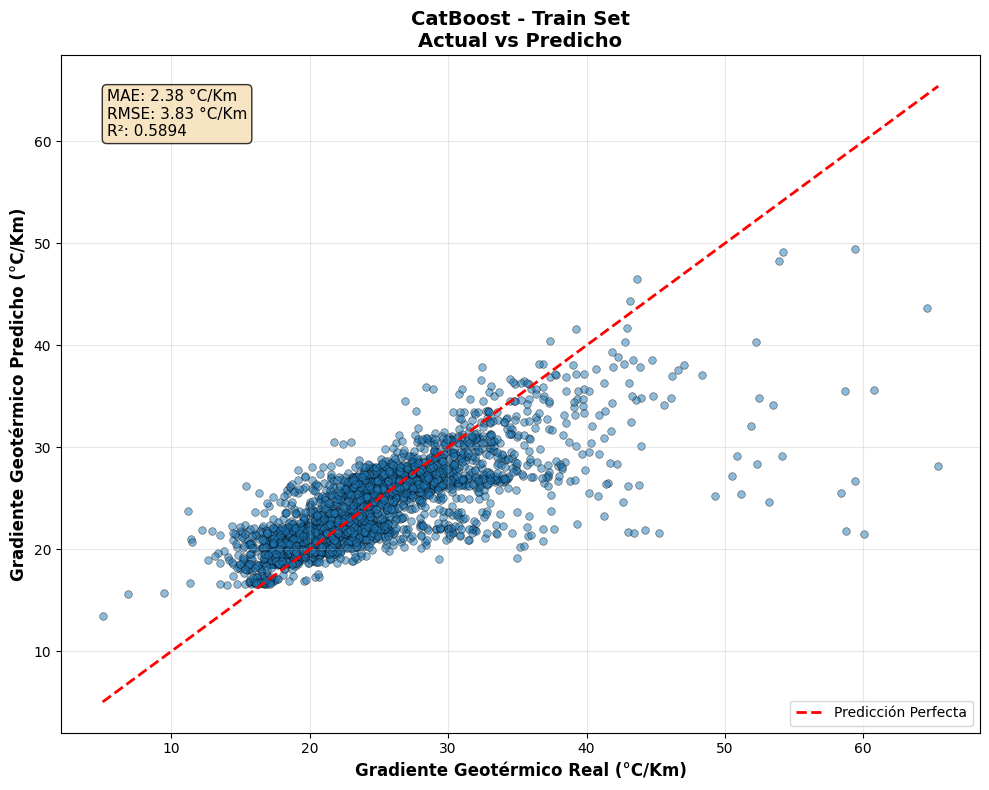

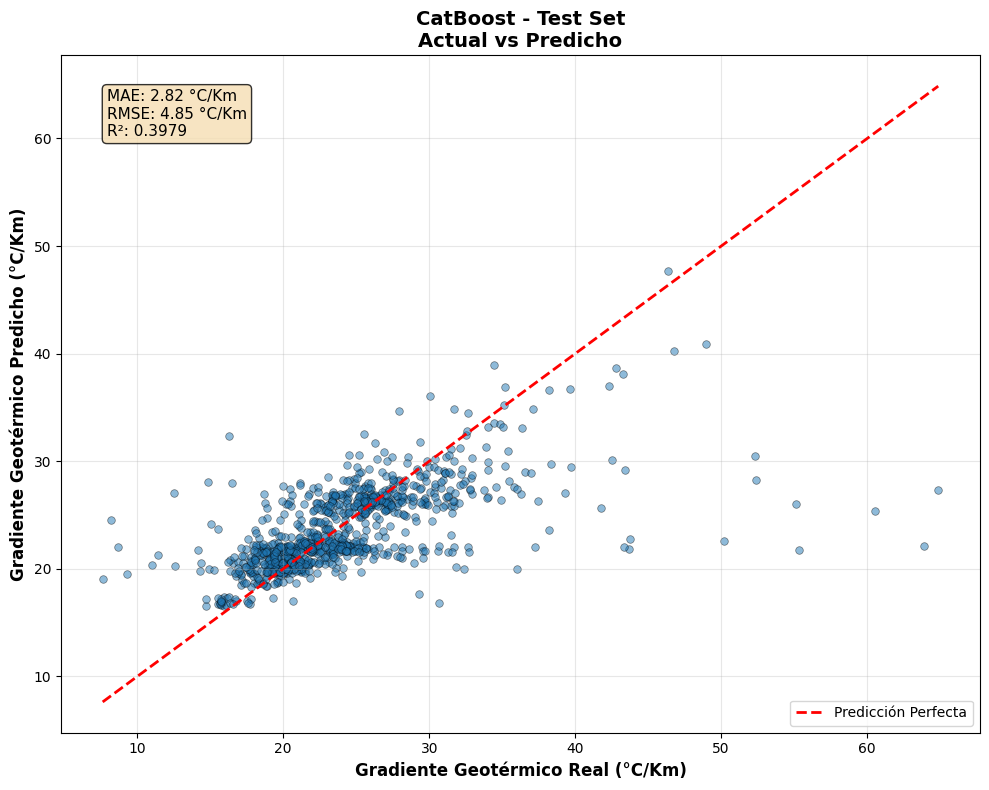

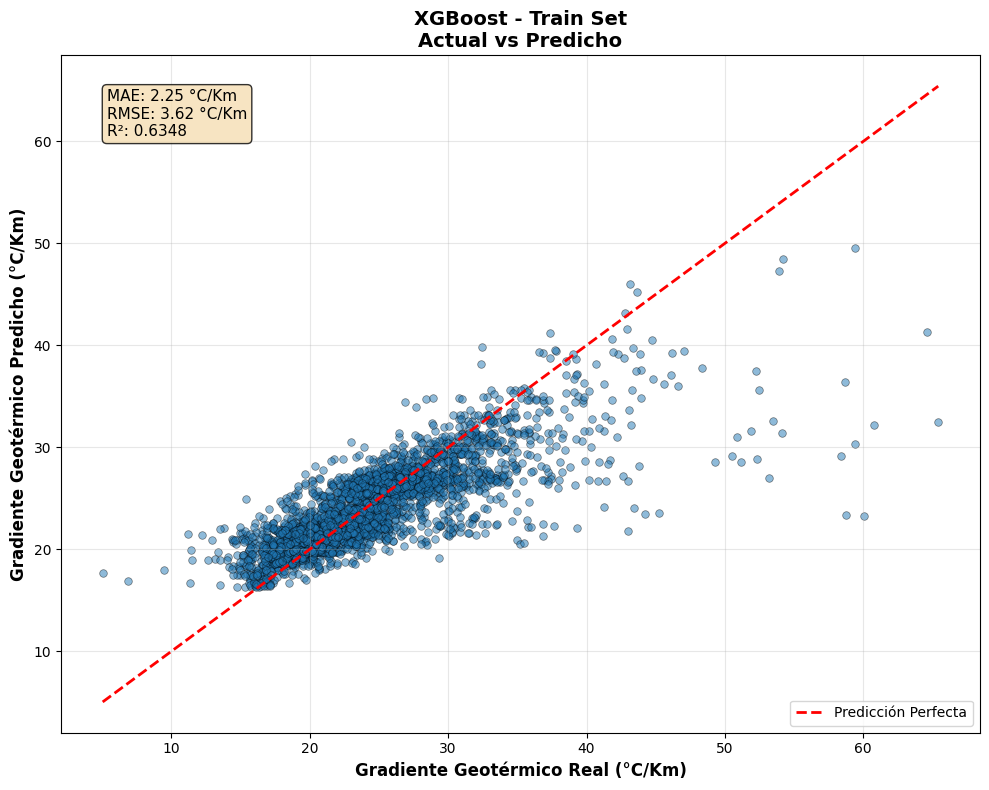

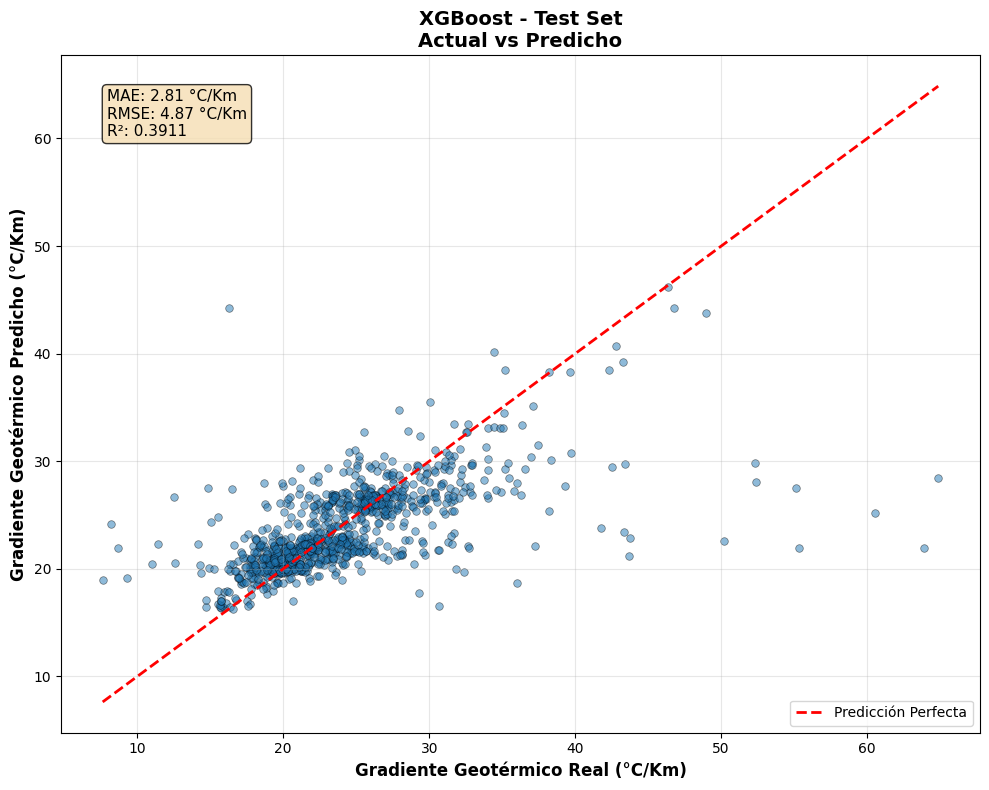

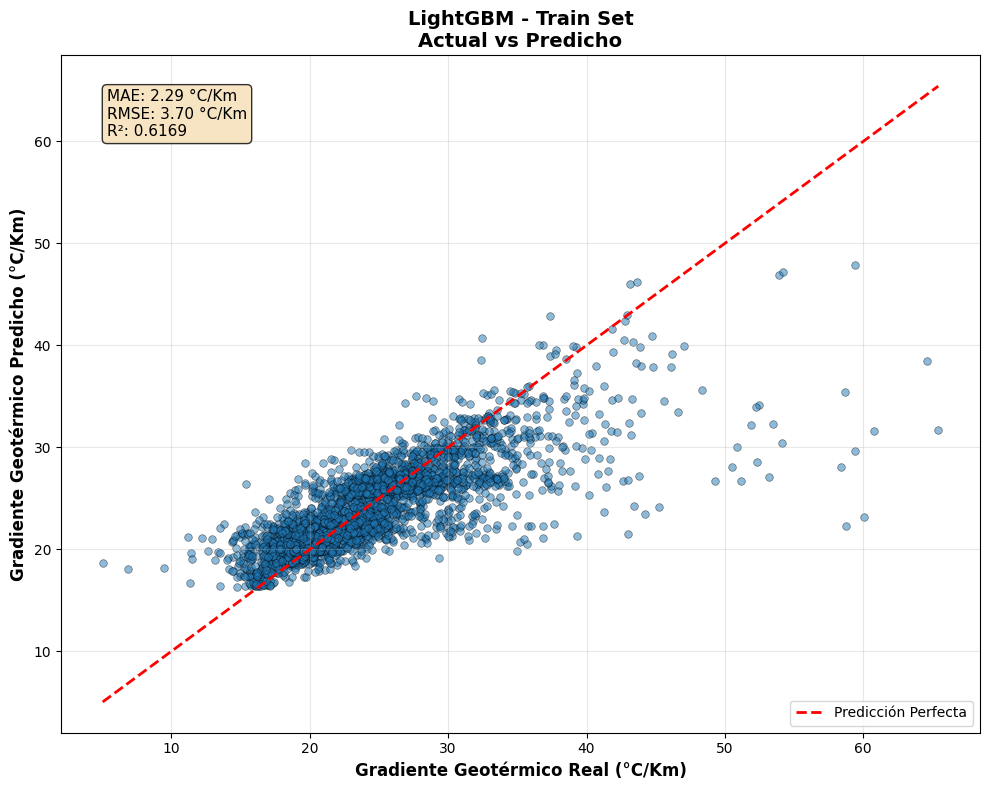

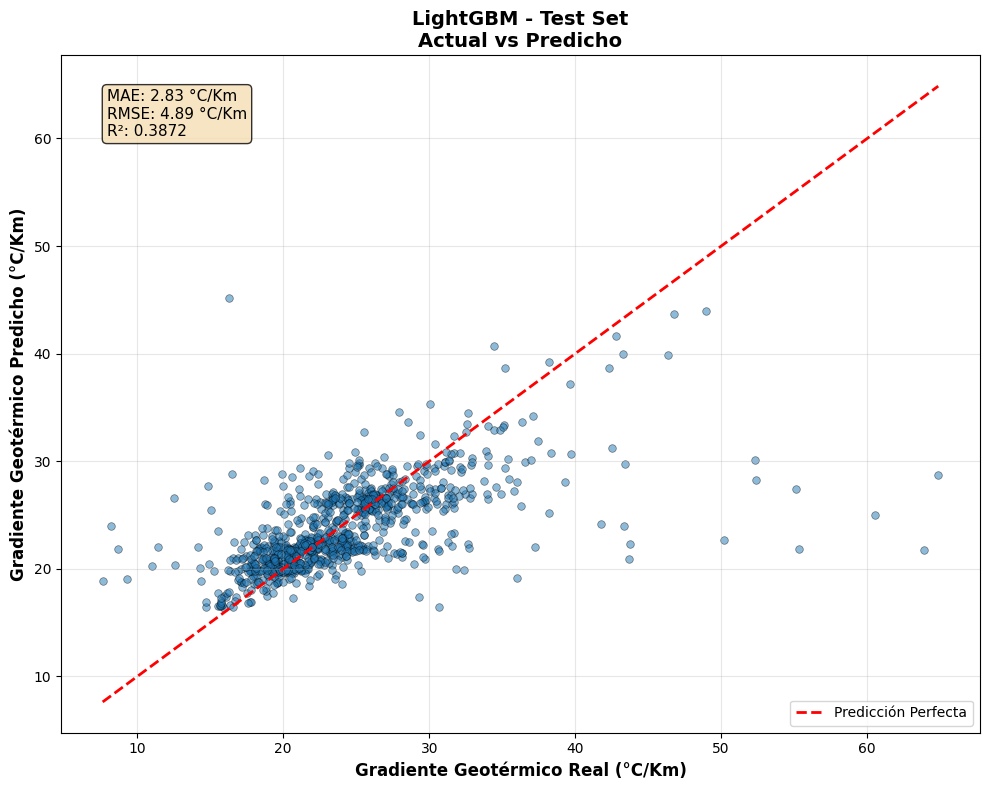

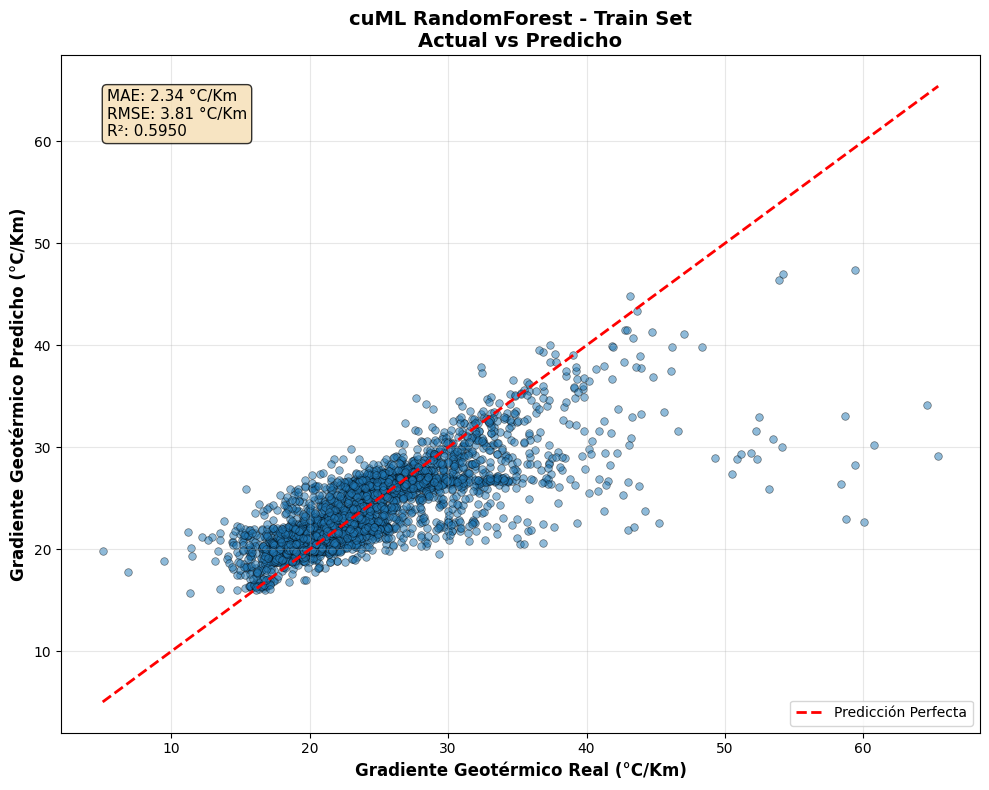

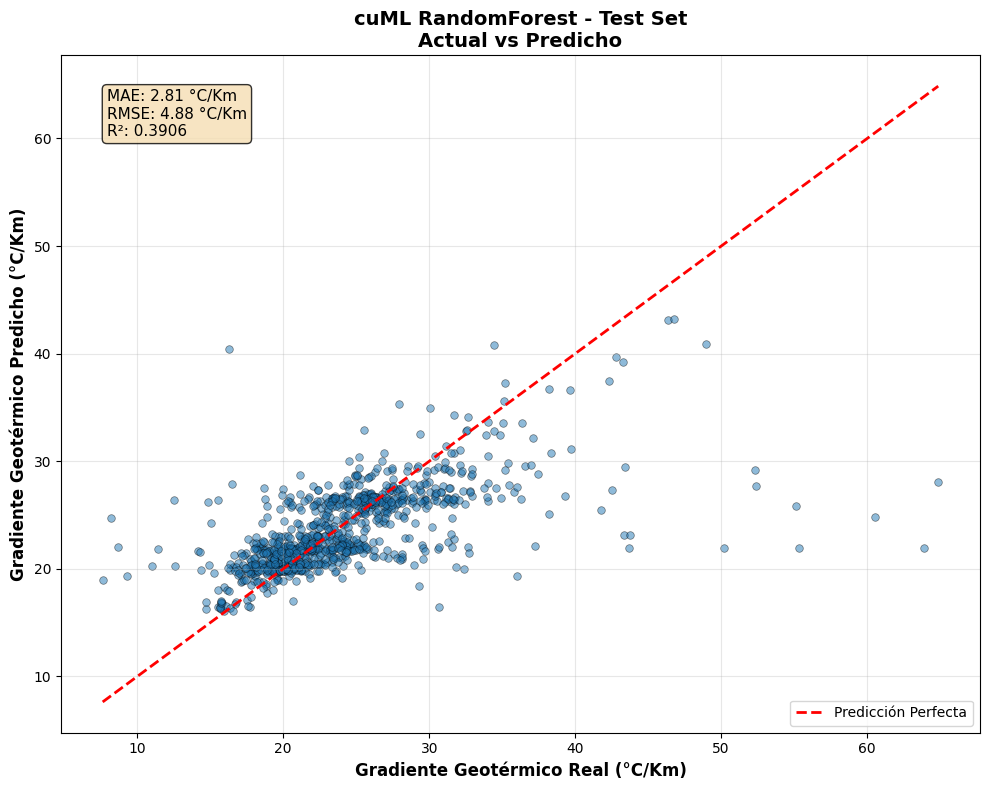

In [66]:
# ==========================================
# FUNCIONES PARA VISUALIZACIÓN
# ==========================================

def plot_actual_vs_predicted(y_actual, y_pred, model_name, dataset_type, save_path):
    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2   = r2_score(y_actual, y_pred)
    plt.figure(figsize=(10, 8))
    plt.scatter(y_actual, y_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')
    plt.xlabel('Gradiente Geotérmico Real (°C/Km)', fontsize=12, fontweight='bold')
    plt.ylabel('Gradiente Geotérmico Predicho (°C/Km)', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - {dataset_type} Set\nActual vs Predicho', fontsize=14, fontweight='bold')
    textstr = f'MAE: {mae:.2f} °C/Km\nRMSE: {rmse:.2f} °C/Km\nR²: {r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', bbox=props)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return mae, rmse, r2


# ==========================================
# APLICAR A CADA MODELO
# ==========================================

# -----CatBoost--------
mae_catb_train, rmse_catb_train, r2_catb_train = plot_actual_vs_predicted(
    y_train_original_scale, y_catb_train_pred_original_scale,
    'CatBoost', 'Train', OUT_DIR / 'catboost_train_plot.png')

mae_catb_test, rmse_catb_test, r2_catb_test = plot_actual_vs_predicted(
    y_test_original_scale, y_catb_test_pred_original_scale,
    'CatBoost', 'Test', OUT_DIR / 'catboost_test_plot.png')

# --- XGBOOST ---
mae_xgb_train, rmse_xgb_train, r2_xgb_train = plot_actual_vs_predicted(
    y_train_original_scale, y_xgb_train_pred_original_scale,
    'XGBoost', 'Train', OUT_DIR / 'xgboost_train_plot.png')

mae_xgb_test, rmse_xgb_test, r2_xgb_test = plot_actual_vs_predicted(
    y_test_original_scale, y_xgb_test_pred_original_scale,
    'XGBoost', 'Test', OUT_DIR / 'xgboost_test_plot.png')

# --- LIGHTGBM ---
mae_lgb_train, rmse_lgb_train, r2_lgb_train = plot_actual_vs_predicted(
    y_train_original_scale, y_lgb_train_pred_original_scale,
    'LightGBM', 'Train', OUT_DIR / 'lightgbm_train_plot.png')

mae_lgb_test, rmse_lgb_test, r2_lgb_test = plot_actual_vs_predicted(
    y_test_original_scale, y_lgb_test_pred_original_scale,
    'LightGBM', 'Test', OUT_DIR / 'lightgbm_test_plot.png')

# --- CUML RANDOM FOREST ---
mae_cuml_rf_train, rmse_cuml_rf_train, r2_cuml_rf_train = plot_actual_vs_predicted(
    y_train_original_scale, y_cuml_rf_train_pred_original_scale,
    'cuML RandomForest', 'Train', OUT_DIR / 'cuml_rf_train_plot.png')

mae_cuml_rf_test, rmse_cuml_rf_test, r2_cuml_rf_test = plot_actual_vs_predicted(
    y_test_original_scale, y_cuml_rf_test_pred_original_scale,
    'cuML RandomForest', 'Test', OUT_DIR / 'cuml_rf_test_plot.png')


In [67]:
# ==========================================
# TABLA RESUMEN — MÉTRICAS NORMALIZADAS
# ==========================================

from sklearn.metrics import mean_squared_error
rmse_train_catb = np.sqrt(mean_squared_error(y_train_train, y_train_pred))

# Recuperar métricas CV del mejor trial de cada modelo
def get_cv(study):
    t = study.best_trial
    return (t.user_attrs["cv_mae_mean"],  t.user_attrs["cv_mae_std"],
            t.user_attrs["cv_mse_mean"],  t.user_attrs["cv_mse_std"],
            t.user_attrs["cv_rmse_mean"], t.user_attrs["cv_rmse_std"],
            t.user_attrs["cv_r2_mean"],   t.user_attrs["cv_r2_std"])

cv_catb    = get_cv(study_cb)
cv_xgb     = get_cv(study_xgb)
cv_lgb     = get_cv(study_lgb)
cv_cuml_rf = get_cv(study_cuml_rf)

df_norm = pd.DataFrame({
    'Modelo':              ['CatBoost', 'XGBoost', 'LightGBM', 'cuML RandomForest'],
    # --- Train ---
    'MAE Train':           [mae_train_catb,    mae_train_xgb,    mae_train_lgb,    mae_train_cuml_rf],
    'RMSE Train':          [rmse_train_catb,   rmse_train_xgb,   rmse_train_lgb,   rmse_train_cuml_rf],
    'R² Train':            [r2_train_catb,     r2_train_xgb,     r2_train_lgb,     r2_train_cuml_rf],
    # --- CV Validación (media ± std) ---
    'MAE CV':              [cv_catb[0],    cv_xgb[0],    cv_lgb[0],    cv_cuml_rf[0]],
    'MAE CV ±std':         [cv_catb[1],    cv_xgb[1],    cv_lgb[1],    cv_cuml_rf[1]],
    'MSE CV':              [cv_catb[2],    cv_xgb[2],    cv_lgb[2],    cv_cuml_rf[2]],
    'MSE CV ±std':         [cv_catb[3],    cv_xgb[3],    cv_lgb[3],    cv_cuml_rf[3]],
    'RMSE CV':             [cv_catb[4],    cv_xgb[4],    cv_lgb[4],    cv_cuml_rf[4]],
    'RMSE CV ±std':        [cv_catb[5],    cv_xgb[5],    cv_lgb[5],    cv_cuml_rf[5]],
    'R² CV':               [cv_catb[6],    cv_xgb[6],    cv_lgb[6],    cv_cuml_rf[6]],
    'R² CV ±std':          [cv_catb[7],    cv_xgb[7],    cv_lgb[7],    cv_cuml_rf[7]],
    # --- Test ---
    'MAE Test':            [mae_test_catb,     mae_test_xgb,     mae_test_lgb,     mae_test_cuml_rf],
    'RMSE Test':           [rmse_test_catb,    rmse_test_xgb,    rmse_test_lgb,    rmse_test_cuml_rf],
    'R² Test':             [r2_test_catb,      r2_test_xgb,      r2_test_lgb,      r2_test_cuml_rf],
}).set_index('Modelo')

print("=" * 90)
print("        MÉTRICAS NORMALIZADAS (espacio Z-score sobre log1p)")
print("=" * 90)
display(df_norm.style
    .format("{:.6f}")
    .highlight_min(subset=['MAE Train','RMSE Train','MAE CV','RMSE CV','MAE Test','RMSE Test'], color='lightgreen')
    .highlight_max(subset=['R² Train','R² CV','R² Test'], color='lightgreen')
    .set_caption("↓ Menor es mejor para MAE/MSE/RMSE   |   ↑ Mayor es mejor para R²   |   CV = validación cruzada del mejor trial (5 folds)")
)


        MÉTRICAS NORMALIZADAS (espacio Z-score sobre log1p)


,MAE Train,RMSE Train,R² Train,MAE CV,MAE CV ±std,MSE CV,MSE CV ±std,RMSE CV,RMSE CV ±std,R² CV,R² CV ±std,MAE Test,RMSE Test,R² Test
Modelo,,,,,,,,,,,,,,
CatBoost,0.420800,0.614803,0.622017,0.488532,0.008970,0.529872,0.038462,0.727432,0.026712,0.469891,0.034248,0.498851,0.778992,0.438963
XGBoost,0.397509,0.580524,0.662992,0.485491,0.011532,0.527639,0.041839,0.725791,0.029445,0.472120,0.038393,0.497177,0.783666,0.432210
LightGBM,0.403555,0.592513,0.648928,0.488401,0.011686,0.531190,0.041641,0.728245,0.029144,0.468647,0.036918,0.500502,0.786152,0.428602
cuML RandomForest,0.413776,0.610289,0.627548,0.486148,0.011340,0.527507,0.040540,0.725739,0.028471,0.472242,0.037055,0.497933,0.782474,0.433937


In [68]:
# ==========================================
# TABLA RESUMEN — MÉTRICAS DESNORMALIZADAS
# ==========================================
# Nota: las métricas CV están en escala normalizada (Z-score sobre log1p).
# Train y Test están en escala original del target (°C/Km).

df_denorm = pd.DataFrame({
    'Modelo':             ['CatBoost', 'XGBoost', 'LightGBM', 'cuML RandomForest'],
    # --- Train ---
    'MAE Train':          [mae_catb_train_denormalized,    mae_xgb_train_denormalized,    mae_lgb_train_denormalized,    mae_cuml_rf_train_denormalized],
    'RMSE Train':         [rmse_catb_train_denormalized,   rmse_xgb_train_denormalized,   rmse_lgb_train_denormalized,   rmse_cuml_rf_train_denormalized],
    'R² Train':           [r2_catb_train_denormalized,     r2_xgb_train_denormalized,     r2_lgb_train_denormalized,     r2_cuml_rf_train_denormalized],
    # --- CV Validación (escala normalizada*) ---
    'MAE CV*':            [cv_catb[0],    cv_xgb[0],    cv_lgb[0],    cv_cuml_rf[0]],
    'RMSE CV*':           [cv_catb[4],    cv_xgb[4],    cv_lgb[4],    cv_cuml_rf[4]],
    'R² CV*':             [cv_catb[6],    cv_xgb[6],    cv_lgb[6],    cv_cuml_rf[6]],
    # --- Test ---
    'MAE Test':           [mae_catb_denormalized,          mae_xgb_denormalized,          mae_lgb_denormalized,          mae_cuml_rf_denormalized],
    'RMSE Test':          [rmse_catb_denormalized,         rmse_xgb_denormalized,         rmse_lgb_denormalized,         rmse_cuml_rf_denormalized],
    'R² Test':            [r2_catb_denormalized,           r2_xgb_denormalized,           r2_lgb_denormalized,           r2_cuml_rf_denormalized],
}).set_index('Modelo')

print("=" * 90)
print("        MÉTRICAS DESNORMALIZADAS (escala original del target)")
print("=" * 90)
print("  * Columnas CV en escala normalizada — no comparables directamente con Train/Test denormalizados")
display(df_denorm.style
    .format("{:.4f}")
    .highlight_min(subset=['MAE Train','RMSE Train','MAE Test','RMSE Test'], color='lightgreen')
    .highlight_max(subset=['R² Train','R² CV*','R² Test'], color='lightgreen')
    .set_caption("↓ Menor es mejor para MAE/RMSE   |   ↑ Mayor es mejor para R²")
)


        MÉTRICAS DESNORMALIZADAS (escala original del target)
  * Columnas CV en escala normalizada — no comparables directamente con Train/Test denormalizados


,MAE Train,RMSE Train,R² Train,MAE CV*,RMSE CV*,R² CV*,MAE Test,RMSE Test,R² Test
Modelo,,,,,,,,,
CatBoost,2.3797,3.8335,0.5894,0.4885,0.7274,0.4699,2.8165,4.8473,0.3979
XGBoost,2.2483,3.6153,0.6348,0.4855,0.7258,0.4721,2.8065,4.8742,0.3911
LightGBM,2.2858,3.7029,0.6169,0.4884,0.7282,0.4686,2.8274,4.8901,0.3872
cuML RandomForest,2.3368,3.8074,0.5950,0.4861,0.7257,0.4722,2.8133,4.8765,0.3906


# **Mapas de Colombia — Gradiente Geotérmico (Real vs Predicho)**

Descargando shapefile...
Extrayendo shapefile...


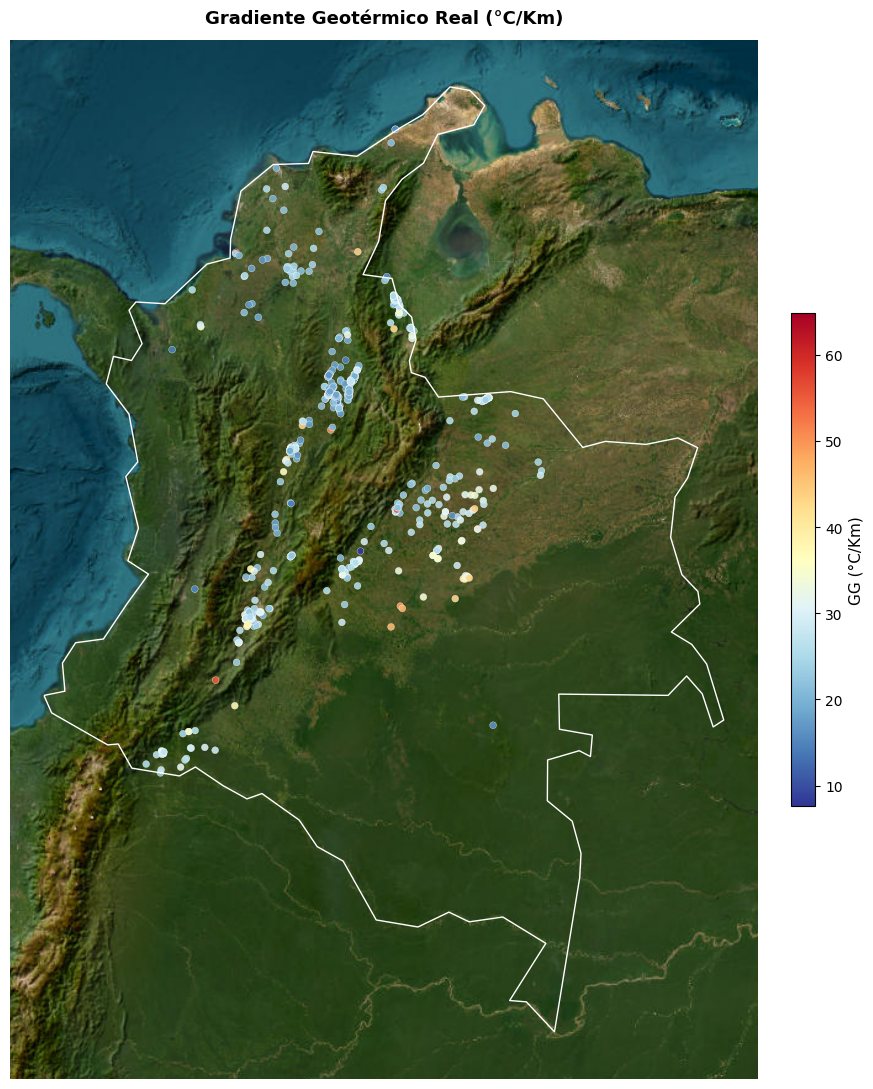

Guardado: mapa_gg_real.png / .pdf


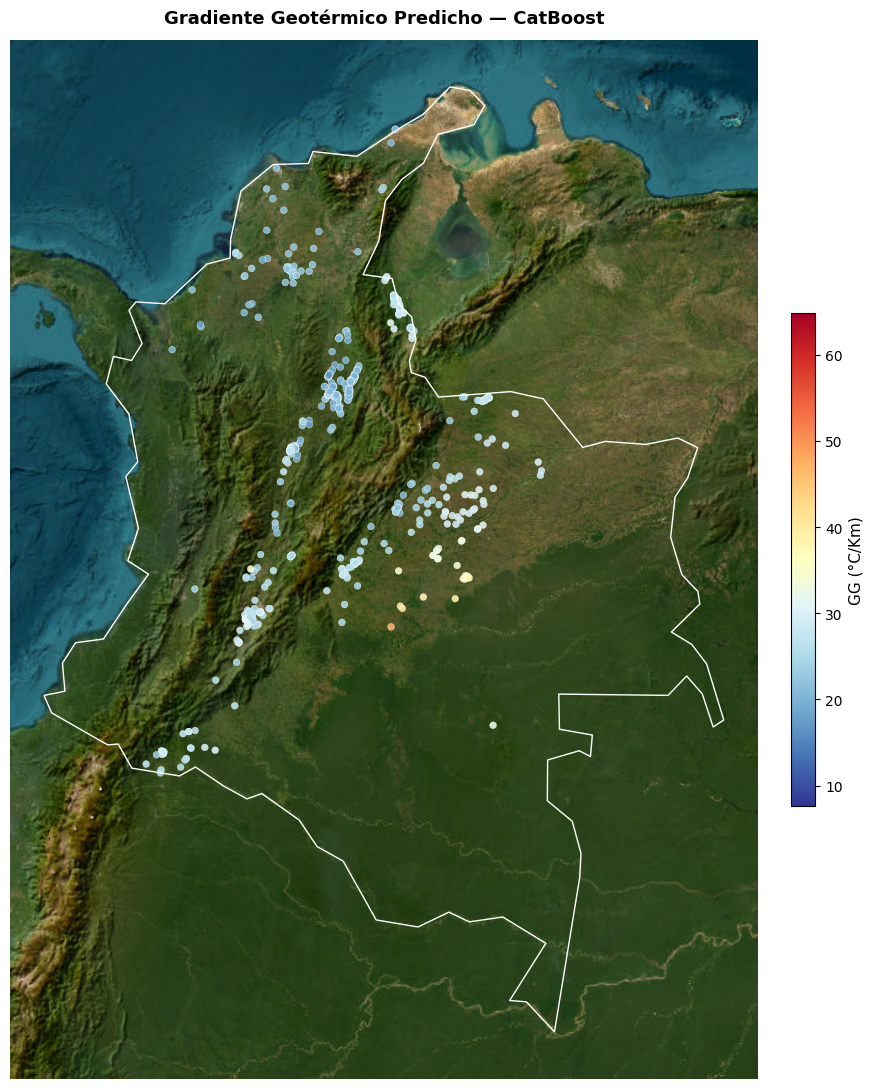

Guardado: mapa_gg_catboost.png / .pdf


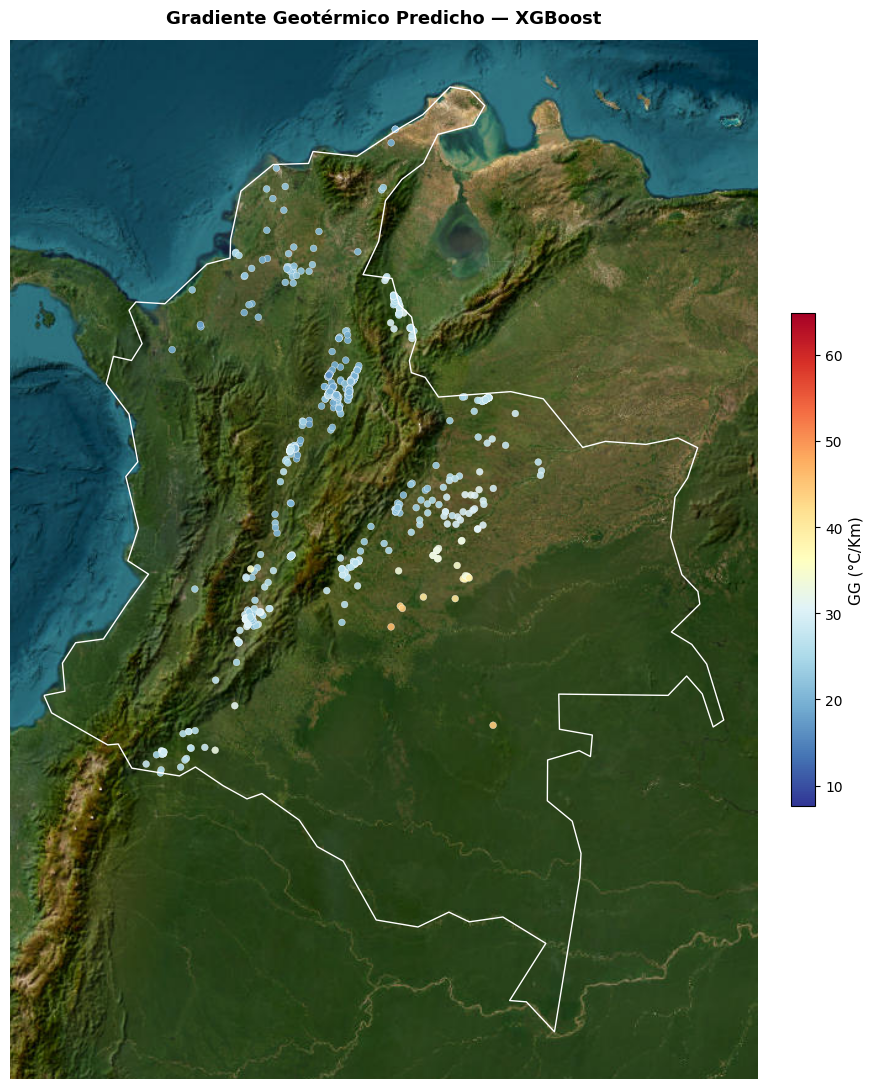

Guardado: mapa_gg_xgboost.png / .pdf


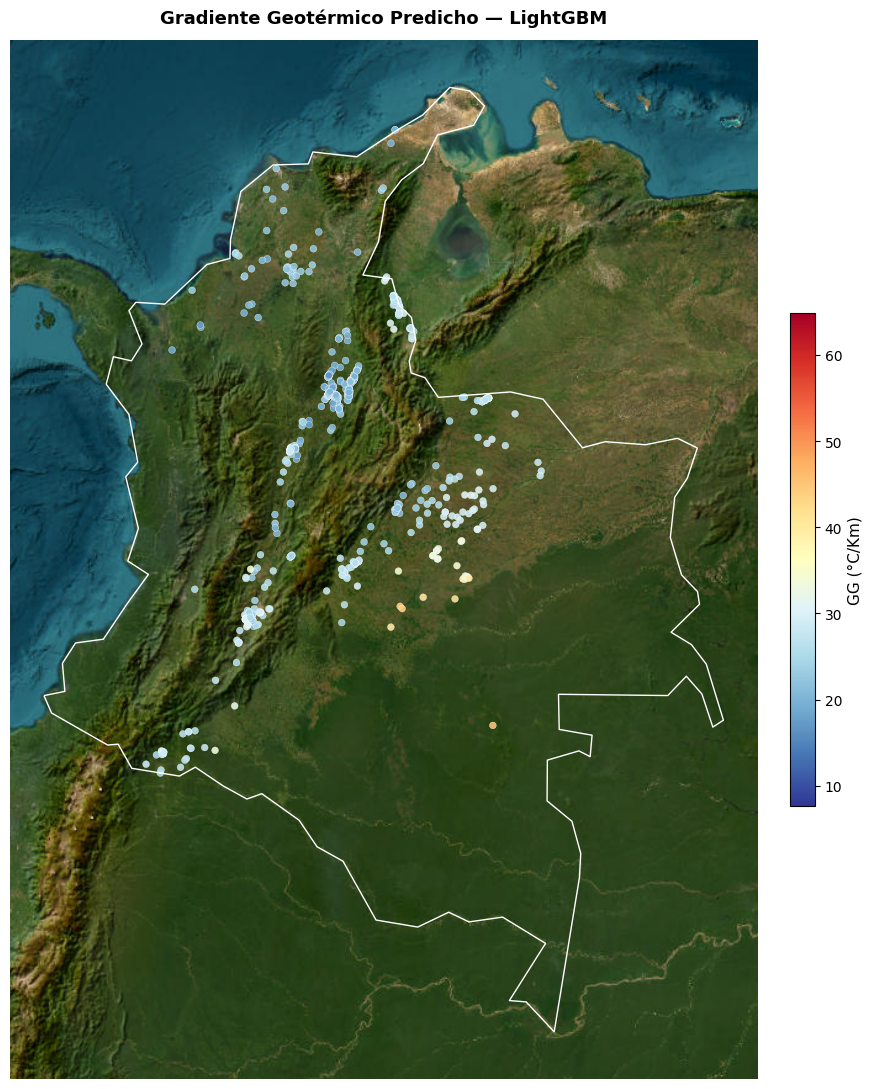

Guardado: mapa_gg_lightgbm.png / .pdf


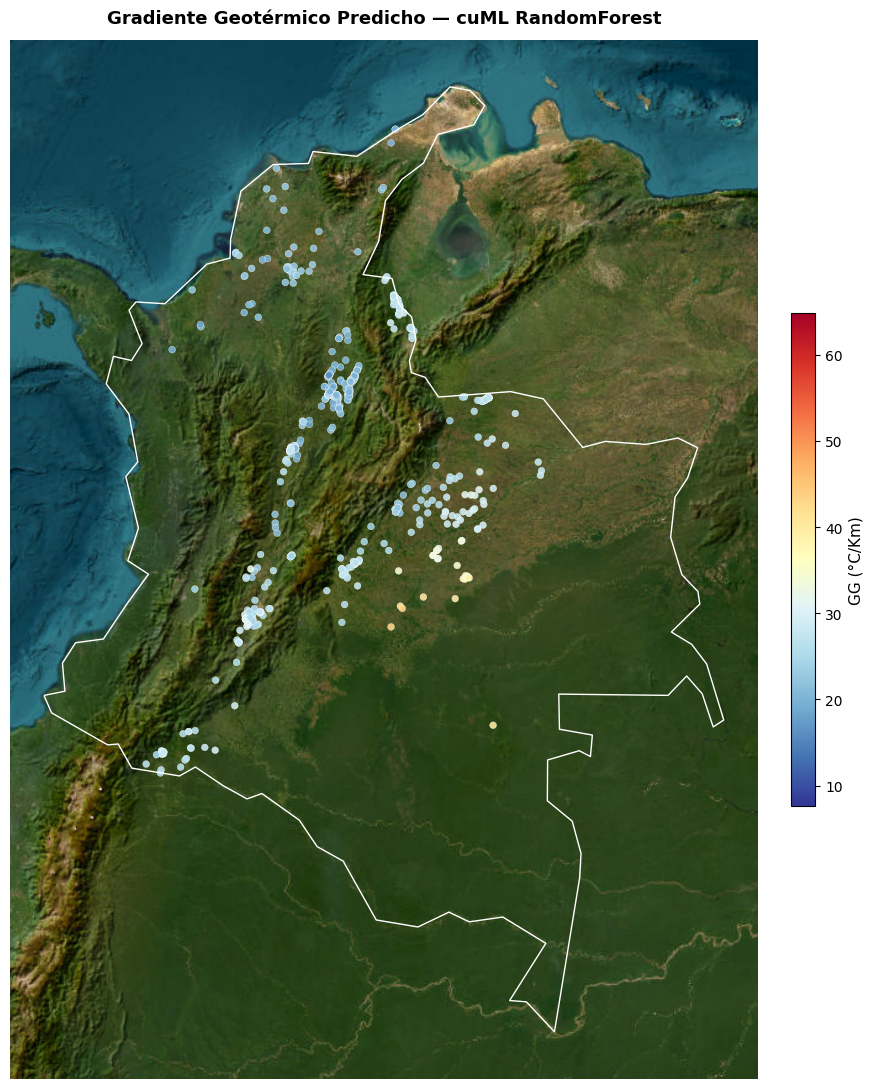

Guardado: mapa_gg_cuml_rf.png / .pdf


In [69]:
import urllib.request
import zipfile
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from shapely.geometry import Point

try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except ImportError:
    HAS_CONTEXTILY = False
    print('contextily no disponible, usando mapa vectorial')

# ── Construir df_map con lat/lon + real + predicciones de cada modelo ────────
df_map = test_df[['Latitude', 'Longitude']].copy().reset_index(drop=True)
df_map['gg_real']    = y_test_original_scale
df_map['gg_catb']    = y_catb_test_pred_original_scale
df_map['gg_xgb']     = y_xgb_test_pred_original_scale
df_map['gg_lgb']     = y_lgb_test_pred_original_scale
df_map['gg_cuml_rf'] = y_cuml_rf_test_pred_original_scale

# ── Descargar shapefile de Colombia ─────────────────────────────────────────
shp_dir  = OUT_DIR / 'colombia_shp'
shp_dir.mkdir(parents=True, exist_ok=True)
zip_path = shp_dir / 'colombia.zip'
shp_path = shp_dir / 'ne_110m_admin_0_countries.shp'
url      = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'

if not zip_path.exists():
    print('Descargando shapefile...')
    urllib.request.urlretrieve(url, zip_path)
if not shp_path.exists():
    print('Extrayendo shapefile...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(shp_dir)

world = gpd.read_file(shp_path).to_crs(4326)
for col in ['ADM0_A3', 'ISO_A3', 'iso_a3']:
    if col in world.columns:
        colombia = world[world[col] == 'COL']
        break
if colombia.empty:
    raise ValueError('No se encontró Colombia en el shapefile.')

# ── Escala de color frio → caliente, unificada para todos los mapas ──────────
cmap = cm.RdYlBu_r
all_vals = pd.concat([
    df_map['gg_real'], df_map['gg_catb'],
    df_map['gg_xgb'], df_map['gg_lgb'], df_map['gg_cuml_rf']
])
vmin = all_vals.min()
vmax = all_vals.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ── Función para generar cada mapa ──────────────────────────────────────────
def plot_mapa(col, titulo, filename):
    gdf = gpd.GeoDataFrame(
        df_map[[col]].copy(),
        geometry=[Point(xy) for xy in zip(df_map['Longitude'], df_map['Latitude'])],
        crs='EPSG:4326'
    )
    fig, ax = plt.subplots(figsize=(9, 11))

    if HAS_CONTEXTILY:
        gdf_web      = gdf.to_crs(epsg=3857)
        colombia_web = colombia.to_crs(epsg=3857)
        colombia_web.boundary.plot(ax=ax, color='white', linewidth=1.0)
        gdf_web.plot(
            column=col, cmap=cmap, vmin=vmin, vmax=vmax,
            markersize=24, alpha=0.90, edgecolor='white',
            linewidth=0.25, legend=False, ax=ax,
        )
        try:
            ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution=False)
        except Exception:
            ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, attribution=False)
        ax.set_axis_off()
    else:
        colombia.plot(ax=ax, color='#d8eecf', edgecolor='black', linewidth=0.8)
        gdf.plot(
            column=col, cmap=cmap, vmin=vmin, vmax=vmax,
            markersize=24, alpha=0.90, edgecolor='white',
            linewidth=0.25, legend=False, ax=ax,
        )
        ax.set_xlabel('Longitud')
        ax.set_ylabel('Latitud')
        ax.set_aspect('equal')

    # Barra de color
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('GG (°C/Km)', fontsize=11)

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f'{filename}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'{filename}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {filename}.png / .pdf')

# ── Generar mapa Real + uno por cada modelo ──────────────────────────────────
plot_mapa('gg_real',    'Gradiente Geotérmico Real (°C/Km)',                'mapa_gg_real')
plot_mapa('gg_catb',    'Gradiente Geotérmico Predicho — CatBoost',         'mapa_gg_catboost')
plot_mapa('gg_xgb',     'Gradiente Geotérmico Predicho — XGBoost',          'mapa_gg_xgboost')
plot_mapa('gg_lgb',     'Gradiente Geotérmico Predicho — LightGBM',         'mapa_gg_lightgbm')
plot_mapa('gg_cuml_rf', 'Gradiente Geotérmico Predicho — cuML RandomForest','mapa_gg_cuml_rf')
